### Explore Bike Share Data

For this project, your goal is to ask and answer three questions about the available bikeshare data from Washington, Chicago, and New York.  This notebook can be submitted directly through the workspace when you are confident in your results.

You will be graded against the project [Rubric](https://review.udacity.com/#!/rubrics/2508/view) by a mentor after you have submitted.  To get you started, you can use the template below, but feel free to be creative in your solutions!

In [88]:
ny = read.csv('new_york_city.csv')
wash = read.csv('washington.csv')
chi = read.csv('chicago.csv')

In [89]:
head(ny)

X,Start.Time,End.Time,Trip.Duration,Start.Station,End.Station,User.Type,Gender,Birth.Year
5688089,2017-06-11 14:55:05,2017-06-11 15:08:21,795,Suffolk St & Stanton St,W Broadway & Spring St,Subscriber,Male,1998
4096714,2017-05-11 15:30:11,2017-05-11 15:41:43,692,Lexington Ave & E 63 St,1 Ave & E 78 St,Subscriber,Male,1981
2173887,2017-03-29 13:26:26,2017-03-29 13:48:31,1325,1 Pl & Clinton St,Henry St & Degraw St,Subscriber,Male,1987
3945638,2017-05-08 19:47:18,2017-05-08 19:59:01,703,Barrow St & Hudson St,W 20 St & 8 Ave,Subscriber,Female,1986
6208972,2017-06-21 07:49:16,2017-06-21 07:54:46,329,1 Ave & E 44 St,E 53 St & 3 Ave,Subscriber,Male,1992
1285652,2017-02-22 18:55:24,2017-02-22 19:12:03,998,State St & Smith St,Bond St & Fulton St,Subscriber,Male,1986


In [90]:
head(wash)

X,Start.Time,End.Time,Trip.Duration,Start.Station,End.Station,User.Type
1621326,2017-06-21 08:36:34,2017-06-21 08:44:43,489.066,14th & Belmont St NW,15th & K St NW,Subscriber
482740,2017-03-11 10:40:00,2017-03-11 10:46:00,402.549,Yuma St & Tenley Circle NW,Connecticut Ave & Yuma St NW,Subscriber
1330037,2017-05-30 01:02:59,2017-05-30 01:13:37,637.251,17th St & Massachusetts Ave NW,5th & K St NW,Subscriber
665458,2017-04-02 07:48:35,2017-04-02 08:19:03,1827.341,Constitution Ave & 2nd St NW/DOL,M St & Pennsylvania Ave NW,Customer
1481135,2017-06-10 08:36:28,2017-06-10 09:02:17,1549.427,Henry Bacon Dr & Lincoln Memorial Circle NW,Maine Ave & 7th St SW,Subscriber
1148202,2017-05-14 07:18:18,2017-05-14 07:24:56,398.000,1st & K St SE,Eastern Market Metro / Pennsylvania Ave & 7th St SE,Subscriber


In [91]:
head(chi)

X,Start.Time,End.Time,Trip.Duration,Start.Station,End.Station,User.Type,Gender,Birth.Year
1423854,2017-06-23 15:09:32,2017-06-23 15:14:53,321,Wood St & Hubbard St,Damen Ave & Chicago Ave,Subscriber,Male,1992
955915,2017-05-25 18:19:03,2017-05-25 18:45:53,1610,Theater on the Lake,Sheffield Ave & Waveland Ave,Subscriber,Female,1992
9031,2017-01-04 08:27:49,2017-01-04 08:34:45,416,May St & Taylor St,Wood St & Taylor St,Subscriber,Male,1981
304487,2017-03-06 13:49:38,2017-03-06 13:55:28,350,Christiana Ave & Lawrence Ave,St. Louis Ave & Balmoral Ave,Subscriber,Male,1986
45207,2017-01-17 14:53:07,2017-01-17 15:02:01,534,Clark St & Randolph St,Desplaines St & Jackson Blvd,Subscriber,Male,1975
1473887,2017-06-26 09:01:20,2017-06-26 09:11:06,586,Clinton St & Washington Blvd,Canal St & Taylor St,Subscriber,Male,1990


### Question 1


**Is there a difference in trip duration between customers and subscribers?**

In [92]:
# First, let's load ggplot2 so that we can visualize our data.
library(ggplot2)

In [93]:
# Next, we'll create a combined dataset, because we don't need them to be separated for this question.
# Unfortunately, the Washington dataset is missing columns, which will make this slightly more complicated.
common_cols <- Reduce(intersect, list(colnames(ny), colnames(wash), colnames(chi)))
ny2 <- ny[, common_cols]
wash2 <- wash[, common_cols]
chi2 <- chi[, common_cols]
combined <- rbind(ny2, wash2, chi2)

In [94]:
# After examining the data, we found that there were several outliers in the dataset, so we will filter out any trips that exceed 100,000 since this is excessively high.
combined <- combined[combined$Trip.Duration < 100000,]

In [95]:
# Some of the User.Type fields have null values, so we will only show data with Customer or Subscriber.
combined <- combined[combined$User.Type == "Customer" | combined$User.Type == "Subscriber",]

In [96]:
# We will create a function so that we can easier compute the means of various datasets and avoid lengthly code.
mean_d <- function(x) {
  mean(x, na.rm = TRUE)
}

In [97]:
# Our subscriber trip duration mean.
subscriber_data <- combined[combined$User.Type == "Subscriber",]

print(mean_d(subscriber_data$Trip.Duration))

[1] 736.0518


In [98]:
# Our customer trip duration mean.
customer_data <- combined[combined$User.Type == "Customer",]

print(mean_d(customer_data$Trip.Duration))

[1] 2300.119


Wow! Based on the data, it appears that our customers have a much longer trip duration on average than our subscribers. Next, we will create a box plot to show any potential biases and visualize the data.

Warning message:
“Removed 4444 rows containing non-finite values (stat_boxplot).”

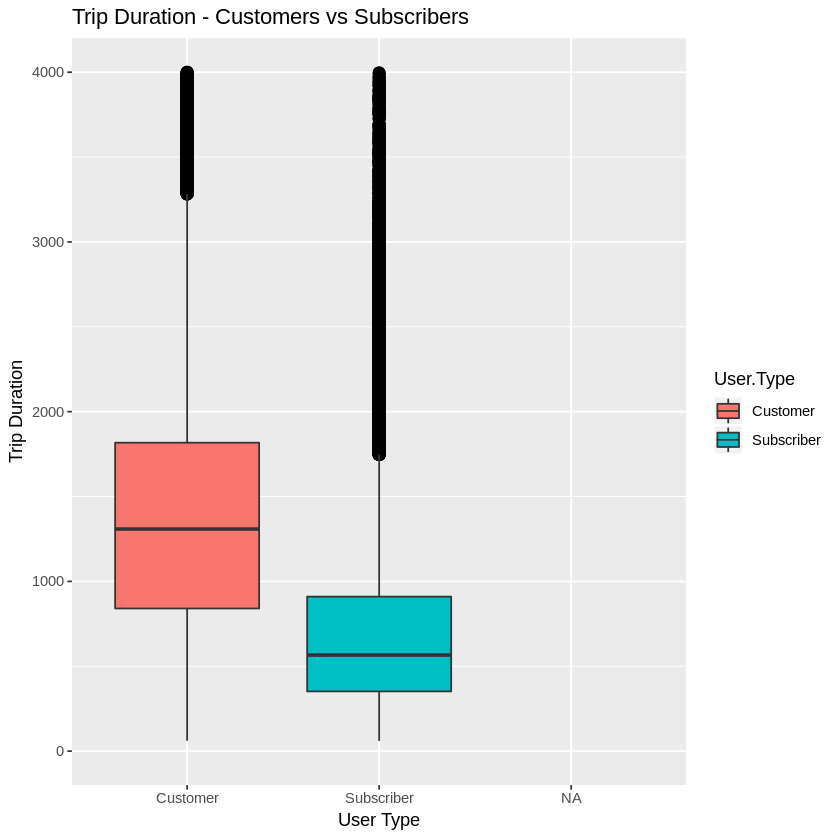

In [99]:
qplot(x = User.Type, y = Trip.Duration, data = combined, 
      geom = "boxplot", fill = User.Type, 
      main = "Trip Duration - Customers vs Subscribers",
      xlab = "User Type", ylab = "Trip Duration",
      outlier.colour = "black", outlier.size = 3) + ylim(0, 4000)

The difference is not nearly as big as we would have thought based on the mean, due to many high outliers in our customer dataset. However, this is still an interesting difference and it may hint that our subscribers have smaller routes than customers on average.

**Based on our analysis, on average, customers have over double the trip duration as subscribers do.**

### Question 2

**Is there a difference in trip duration in different cities?**

In [100]:
# First, let's check the mean of Trip.Duration for each dataset.
# New York
print(mean_d(ny$Trip.Duration))

[1] 903.6147


In [101]:
# Washington
print(mean_d(wash$Trip.Duration))

[1] 1233.953


In [102]:
# Chicago
print(mean_d(chi$Trip.Duration))

[1] 937.1728


Based on our results so far, it appears as though New York and Chicago have similar means, but Washington is definitely higher for some reason. Let's investigate this with another box plot.

In [103]:
# Let's add a new City column to our datasets so that we can use this for our qplot.
ny = read.csv('new_york_city.csv')
wash = read.csv('washington.csv')
chi = read.csv('chicago.csv')
ny$City <- "New York"
wash$City <- "Washington"
chi$City <- "Chicago"

Warning message:
“Removed 715 rows containing non-finite values (stat_boxplot).”Warning message:
“Removed 5788 rows containing non-finite values (stat_boxplot).”Warning message:
“Removed 249 rows containing non-finite values (stat_boxplot).”

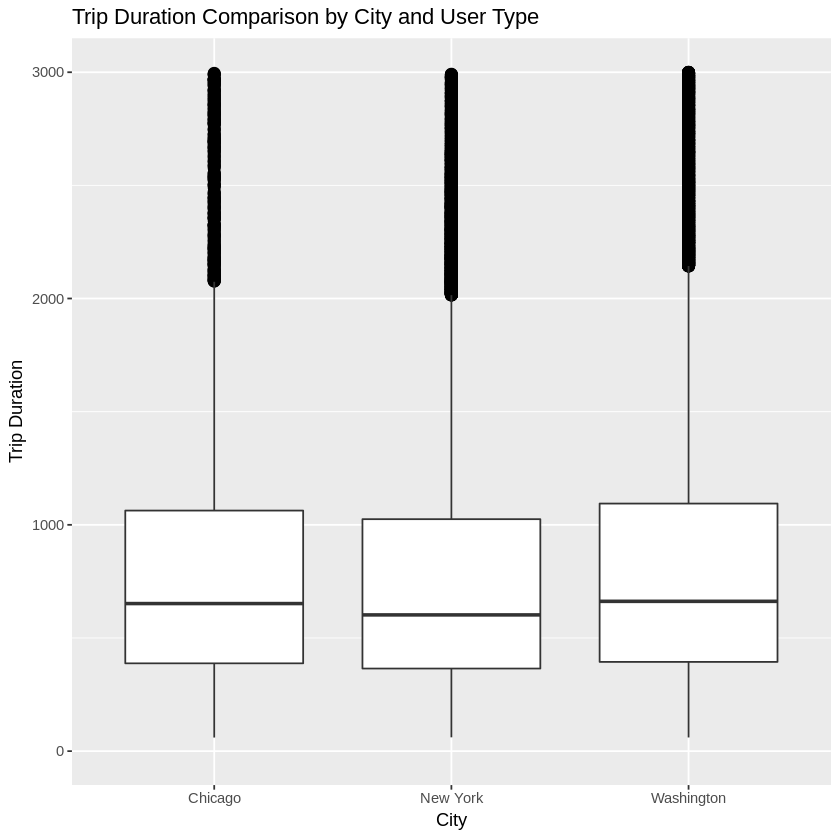

In [104]:
qplot(x = City, y = Trip.Duration, data = ny, 
      geom = "boxplot",
      main = "Trip Duration Comparison by City and User Type",
      xlab = "City", ylab = "Trip Duration",
      outlier.colour = "black", outlier.size = 3) +
  geom_boxplot(data = wash, aes(x = City, y = Trip.Duration), 
               outlier.colour = "black", outlier.size = 3) +
  geom_boxplot(data = chi, aes(x = City, y = Trip.Duration), 
               outlier.colour = "black", outlier.size = 3) + ylim(0,3000)

As you can see, despite the higher mean, the box plots show us that there isn't a huge difference here. If anything, all three cities have very similar trip durations among users of our bikes.

**Based on our analysis, there is no major difference between any of the three cities in trip durations.**

### Question 3

**Is there a difference in trip duration based on gender?**

In [105]:
# Since only two of our datasets have the Gender column, let's construct a new dataset to work with.
gender_data <- rbind(ny, chi)

In [106]:
# The mean of male trip duration.
male_data <- gender_data[gender_data$Gender == "Male",]

print(mean_d(male_data$Trip.Duration))

[1] 755.096


In [107]:
female_data <- gender_data[gender_data$Gender == "Female",]

print(mean_d(female_data$Trip.Duration))

[1] 863.3226


Interesting! Females seem to have longer trip durations than males, on average. Let's create a bar chart to visualize the difference.

Warning message:
“Ignoring unknown parameters: fun”Warning message:
“Removed 1 rows containing non-finite values (stat_summary).”No summary function supplied, defaulting to `mean_se()


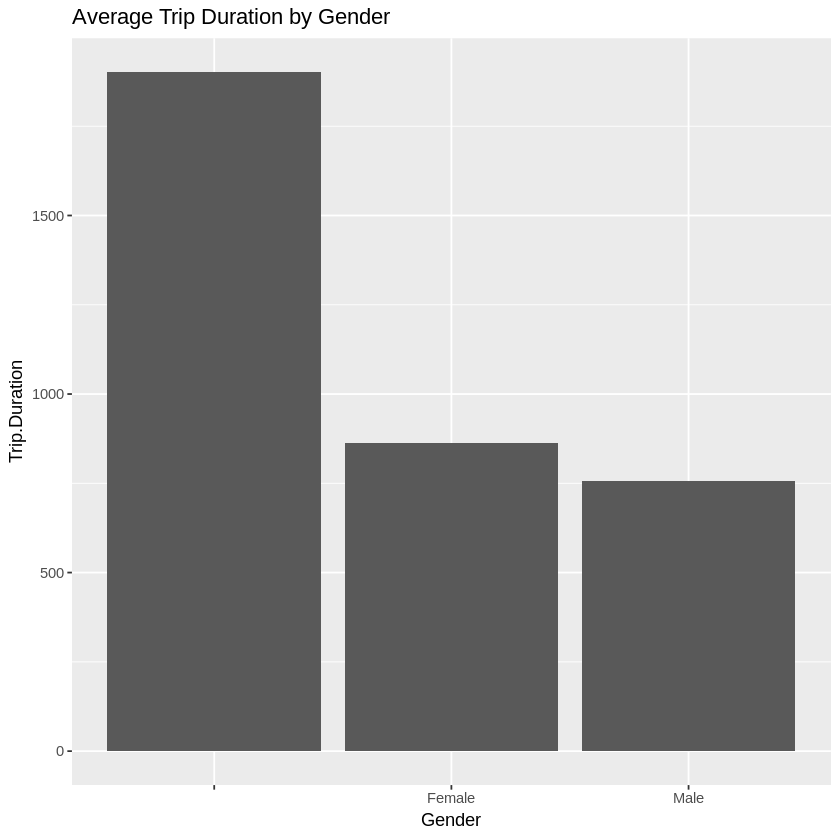

In [108]:
ggplot(gender_data, aes(Gender, Trip.Duration)) +
  stat_summary(fun = mean, geom = "bar") +
  labs(title = "Average Trip Duration by Gender")

It appears that people with missing data for gender in our dataset traveled much longer than those with a specified gender! This is relatively surprising and should be investigated more carefully, as it is possible this represents invalid data. However, it is nonetheless interesting to note that females do have slightly longer trip durations than males.

**Females have slightly longer trip durations than males, although those without an assigned gender in the dataset were almost double the averages of those with an assigned gender.**


## Finishing Up

> Congratulations!  You have reached the end of the Explore Bikeshare Data Project. You should be very proud of all you have accomplished!

> **Tip**: Once you are satisfied with your work here, check over your report to make sure that it is satisfies all the areas of the [rubric](https://review.udacity.com/#!/rubrics/2508/view). 


## Directions to Submit

> Before you submit your project, you need to create a .html or .pdf version of this notebook in the workspace here. To do that, run the code cell below. If it worked correctly, you should get a return code of 0, and you should see the generated .html file in the workspace directory (click on the orange Jupyter icon in the upper left).

> Alternatively, you can download this report as .html via the **File** > **Download as** submenu, and then manually upload it into the workspace directory by clicking on the orange Jupyter icon in the upper left, then using the Upload button.

> Once you've done this, you can submit your project by clicking on the "Submit Project" button in the lower right here. This will create and submit a zip file with this .ipynb doc and the .html or .pdf version you created. Congratulations!

In [109]:
system('python -m nbconvert Explore_bikeshare_data.ipynb')